In [4]:
# BLOCK 1: ENVIRONMENT INITIALIZATION, SEED CONTROL, AND DRIVE MOUNTING

import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

# 1. Responding to Reviewer 2's Criticism: Establishing Strict Seed Control
# to ensure the stability and reproducibility of the results
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Fixing the Google Drive Connection

from google.colab import drive
try:
    # Forcing a Remount to Avoid Credential Propagation Errors
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive was successfully accessed.")
except Exception as e:
    print(f"FAILED TO MOUNT DRIVE: {e}")
    print("Solution: Perform a 'Factory Reset Runtime' or check the internet connection.")

# 3. Directory Setup
DATA_DIR = "/content/drive/MyDrive/bilstm"
SAVE_DIR = "/content/drive/MyDrive/bilstm/Outputs"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

print("=" * 60)
print("ENVIRONMENT SETUP SUCCESSFUL")
print(f"Device Used : {DEVICE}")
print(f"Data Directory  : {DATA_DIR}")
print("=" * 60)

Mounted at /content/drive
Google Drive was successfully accessed.
ENVIRONMENT SETUP SUCCESSFUL
Device Used : cuda
Data Directory  : /content/drive/MyDrive/bilstm


In [5]:
# BLOK 2 DATA LOADING, DUPLICATE/NaN INSPECTION, & STATISTICS

def safe_read_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File not found: {path}. Check its name and location!")
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df

def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

print("Loading and merging the multimodal dataset...")

# 1. LOAD YAHOO (Market Data)
yahoo_df = safe_read_csv("crudeoil2026.csv")
yahoo_df["Date"] = pd.to_datetime(yahoo_df["Date"])
for col in ["Open", "High", "Low", "Close", "Volume"]:
    yahoo_df[col] = clean_numeric(yahoo_df[col])
yahoo_df.sort_values("Date", inplace=True)
yahoo_df.reset_index(drop=True, inplace=True)

# 2. LOAD EIA (Spot Price)
eia_df = safe_read_csv("WTI2026.csv")
eia_df.rename(columns={"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)": "WTI_Spot_Price"}, inplace=True)
eia_df["Date"] = pd.to_datetime(eia_df["Date"])
eia_df["WTI_Spot_Price"] = clean_numeric(eia_df["WTI_Spot_Price"])
eia_df["WTI_Spot_Return_1d"] = eia_df["WTI_Spot_Price"].pct_change(1)
eia_df.sort_values("Date", inplace=True)

# 3. LOAD SENTIMENT (FinBERT StockTwits)
sent_df = safe_read_csv("finbert_daily_sentiment_NEW.csv")
sent_df["Date"] = pd.to_datetime(sent_df["Date"])
for col in ["daily_finbert_score", "message_count"]:
    sent_df[col] = clean_numeric(sent_df[col])
sent_df["rolling_mean_sentiment_3d"] = sent_df["daily_finbert_score"].rolling(3, min_periods=1).mean()
sent_df.sort_values("Date", inplace=True)

# 4. LOAD PORTWATCH (Supply Chain)
port_df = safe_read_csv("Daily_Ports_Data.csv")
port_df.columns = port_df.columns.str.lower()
port_df["date"] = pd.to_datetime(port_df["date"], errors="coerce")
port_df = port_df.groupby("date")[["portcalls_tanker", "import_tanker", "export_tanker"]].sum().reset_index()
port_df.rename(columns={"date": "Date"}, inplace=True)
port_df["portcalls_lag2"] = port_df["portcalls_tanker"].shift(2)
port_df["import_lag2"]    = port_df["import_tanker"].shift(2)
port_df["export_lag2"]    = port_df["export_tanker"].shift(2)
port_df = port_df[["Date", "portcalls_lag2", "import_lag2", "export_lag2"]]
port_df.sort_values("Date", inplace=True)

# 5. DATA MERGING (LEFT JOIN ke Timeline Trading Yahoo)
merged = yahoo_df.merge(eia_df[["Date", "WTI_Spot_Price", "WTI_Spot_Return_1d"]], on="Date", how="left")
merged = merged.merge(sent_df, on="Date", how="left")
merged = merged.merge(port_df, on="Date", how="left")

# DUPLICATE INSPECTION
print("\n[INITIAL DATA INSPECTION]")
dup_count = merged.duplicated().sum()
print(f"Number of duplicate rows found: {dup_count}")
if dup_count > 0:
    merged.drop_duplicates(inplace=True)
    print("-> Duplicate rows have been removed.")

# INSPECTION OF MISSING VALUES (NaN) BEFORE IMPUTATION
missing_awal = merged.isnull().sum()
print(f"Columns with Missing Values (NaN) Before Processing:")
missing_cols = missing_awal[missing_awal > 0]
if not missing_cols.empty:
    for col, val in missing_cols.items():
        print(f"  - {col}: {val} Blank Rows")
else:
    print("  - No NaN detected (Data is complete).")

# 6. TARGET CREATION (future_5day_avg_close)
close = merged["Close"]
merged["future_5day_avg_close"] = (
    close.shift(-1) + close.shift(-2) + close.shift(-3) + close.shift(-4) + close.shift(-5)
) / 5

# 7. TECHNICAL FEATURE ENGINEERING
merged["EMA_20"] = close.ewm(span=20, adjust=False).mean()
delta = close.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
merged["RSI_14"] = 100 - (100 / (1 + rs))

merged["return_1d"] = close.pct_change(1)
merged["return_3d"] = close.pct_change(3)
merged["return_5d"] = close.pct_change(5)
merged["range_hl"] = (merged["High"] - merged["Low"]) / close
merged["volatility_5"] = merged["return_1d"].rolling(5, min_periods=1).std()

FEATURE_COLS = [
    "Open", "High", "Low", "Volume", "Close",
    "WTI_Spot_Price", "EMA_20", "RSI_14",
    "return_1d", "return_3d", "return_5d",
    "range_hl", "volatility_5", "WTI_Spot_Return_1d",
    "daily_finbert_score", "message_count", "rolling_mean_sentiment_3d",
    "portcalls_lag2", "import_lag2", "export_lag2"
]
TARGET_COL = "future_5day_avg_close"

# 8. LOOK-AHEAD BIAS RESOLUTION
merged.sort_values("Date", inplace=True)
merged[FEATURE_COLS] = merged[FEATURE_COLS].ffill()
merged.dropna(subset=FEATURE_COLS + [TARGET_COL], inplace=True)
merged.reset_index(drop=True, inplace=True)

print(f"\n[FINAL CLEAN DATA]")
print(f"Dataset Dimensions: {merged.shape[0]} Rows, {len(FEATURE_COLS)} Features + 1 Target")

# 9. PRINT DESCRIPTIVE STATISTICS
desc_stats = pd.DataFrame({
    'Mean': merged[FEATURE_COLS].mean(),
    'Std': merged[FEATURE_COLS].std(),
    'Skewness': merged[FEATURE_COLS].skew(),
    'Kurtosis': merged[FEATURE_COLS].kurt(),
    '% Final Missing Values': merged[FEATURE_COLS].isnull().mean() * 100
})

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS TABLE")
print("=" * 60)
print(desc_stats.round(4).to_string())
print("=" * 60)

Loading and merging the multimodal dataset...

[INITIAL DATA INSPECTION]
Number of duplicate rows found: 0
Columns with Missing Values (NaN) Before Processing:
  - Volume: 12 Blank Rows
  - WTI_Spot_Price: 17 Blank Rows
  - WTI_Spot_Return_1d: 18 Blank Rows
  - daily_finbert_score: 4644 Blank Rows
  - message_count: 4644 Blank Rows
  - rolling_mean_sentiment_3d: 4644 Blank Rows
  - portcalls_lag2: 4609 Blank Rows
  - import_lag2: 4609 Blank Rows
  - export_lag2: 4609 Blank Rows

[FINAL CLEAN DATA]
Dataset Dimensions: 1795 Rows, 20 Features + 1 Target

DESCRIPTIVE STATISTICS TABLE
                                   Mean           Std  Skewness   Kurtosis  % Final Missing Values
Open                       6.802600e+01  1.775250e+01   -0.0515     0.9089                     0.0
High                       6.921260e+01  1.800010e+01    0.0775     0.7516                     0.0
Low                        6.674380e+01  1.753740e+01   -0.2645     1.5597                     0.0
Volume           

In [6]:
# BLOK 3: WALK-FORWARD CROSS-VALIDATION & SEQUENCE GENERATION

class SequenceDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        return (
            self.X[idx : idx + self.seq_len],
            self.y[idx + self.seq_len]
        )

def create_walk_forward_splits(df, feature_cols, target_col, n_splits=5, seq_len=30):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    splits = []

    # Extract NumPy Array
    X_raw = df[feature_cols].values
    y_raw = df[[target_col]].values

    print(f"\n[BUILDING {n_splits}-FOLD WALK-FORWARD CV DENGAN SEQ_LEN = {seq_len}]")
    print("-" * 60)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_raw)):
        # 1. Separate Raw Data
        X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
        y_train_raw, y_test_raw = y_raw[train_idx], y_raw[test_idx]

        # 2. Initialize and Fit the Scaler ONLY on the Training Set
        x_scaler = RobustScaler()
        y_scaler = RobustScaler()

        X_train_scaled = x_scaler.fit_transform(X_train_raw)
        y_train_scaled = y_scaler.fit_transform(y_train_raw).flatten()

        # 3. Transform on the Test Set
        X_test_scaled = x_scaler.transform(X_test_raw)
        y_test_scaled = y_scaler.transform(y_test_raw).flatten()

        # 4. Create Tensor Dataset with Sliding Window
        train_dataset = SequenceDataset(X_train_scaled, y_train_scaled, seq_len)
        test_dataset = SequenceDataset(X_test_scaled, y_test_scaled, seq_len)

        splits.append({
            'fold': fold + 1,
            'train_dataset': train_dataset,
            'test_dataset': test_dataset,
            'x_scaler': x_scaler,
            'y_scaler': y_scaler,
            'test_idx': test_idx # Saving the Original Indices for Plotting
        })

        print(f"Fold {fold + 1}:")
        print(f"  Train: {len(train_idx)} Raw Observations -> {len(train_dataset)} sequences")
        print(f"  Test : {len(test_idx)} Raw Observations -> {len(test_dataset)} sequences")

    print("-" * 60)
    return splits

SEQ_LEN = 30
N_SPLITS = 5
cv_splits = create_walk_forward_splits(merged, FEATURE_COLS, TARGET_COL, n_splits=N_SPLITS, seq_len=SEQ_LEN)


[BUILDING 5-FOLD WALK-FORWARD CV DENGAN SEQ_LEN = 30]
------------------------------------------------------------
Fold 1:
  Train: 300 Raw Observations -> 270 sequences
  Test : 299 Raw Observations -> 269 sequences
Fold 2:
  Train: 599 Raw Observations -> 569 sequences
  Test : 299 Raw Observations -> 269 sequences
Fold 3:
  Train: 898 Raw Observations -> 868 sequences
  Test : 299 Raw Observations -> 269 sequences
Fold 4:
  Train: 1197 Raw Observations -> 1167 sequences
  Test : 299 Raw Observations -> 269 sequences
Fold 5:
  Train: 1496 Raw Observations -> 1466 sequences
  Test : 299 Raw Observations -> 269 sequences
------------------------------------------------------------


In [8]:
# BLOK 4: BiLSTM ARCHITECTURE, EVALUATION METRICS, AND TRAINING FUNCTION

import copy
from torch.utils.data import DataLoader, Subset

class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2, dense_hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, dense_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_hidden, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, features)
        out, _ = self.lstm(x)
        # Extraction of the Hidden State from the Last Time-Step
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze(-1)

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))

    epsilon = 1e-8
    # Conventional MAPE
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100

    # SMAPE (Symmetric MAPE)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + epsilon))

    r2 = r2_score(y_true, y_pred)

    return rmse, mae, mape, smape, r2

def train_evaluate_fold(train_dataset, test_dataset, input_size, device, y_scaler, fold_idx, seed=42):
    """
    Training function for one iteration (fold).
    Reserve 15% of the final training data chronologically for validation (Early Stopping).
    """
    torch.manual_seed(seed)

    n_total = len(train_dataset)
    n_val = max(1, int(n_total * 0.15))

    # Chronological Split for Validation (No Shuffling for Time-Series)
    train_idx = list(range(0, n_total - n_val))
    val_idx = list(range(n_total - n_val, n_total))

    train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=32, shuffle=True, drop_last=False)
    val_loader = DataLoader(Subset(train_dataset, val_idx), batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = BiLSTMRegressor(input_size).to(device)
    criterion = nn.HuberLoss() # Handling Outliers as Recommended
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    epochs = 150
    patience = 15
    best_val_loss = np.inf
    patience_counter = 0
    best_model_state = None

    print(f"--- Training Fold {fold_idx} (Seed {seed}) ---")

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_losses.append(criterion(preds, yb).item())

        avg_val_loss = np.mean(val_losses)

        # Mekanisme Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"    Early stopping at Epoch {epoch+1}. Best Val Loss: {best_val_loss:.6f}")
            break

    # Loading the best weights before inference
    model.load_state_dict(best_model_state)
    model.eval()

    preds_all = []
    y_all = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds_all.extend(model(xb).cpu().numpy())
            y_all.extend(yb.numpy())

    # Inverse Transform to Return to the Original Price Domain (USD/barrel)
    preds_inv = y_scaler.inverse_transform(np.array(preds_all).reshape(-1, 1)).flatten()
    y_inv = y_scaler.inverse_transform(np.array(y_all).reshape(-1, 1)).flatten()

    rmse, mae, mape, smape, r2 = compute_metrics(y_inv, preds_inv)

    return {
        "rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "r2": r2,
        "y_true": y_inv, "y_pred": preds_inv
    }

print("The BiLSTM Architecture and Evaluation Metrics Functions Have Been Successfully Loaded.")

The BiLSTM Architecture and Evaluation Metrics Functions Have Been Successfully Loaded.


In [9]:
# BLOCK 5: TRAINING EXECUTION (5 FOLDS x 5 SEEDS) FOR FULL MULTIMODAL

SEEDS = [0, 42, 123, 777, 999]
input_size = len(FEATURE_COLS)

print("=" * 60)
print(f"STARTING TRAINING: {N_SPLITS} FOLDS x {len(SEEDS)} SEEDS")
print(f"Total Training Iterations: {N_SPLITS * len(SEEDS)}")
print("=" * 60)

# Store results for aggregation
all_fold_results = []

for fold_data in cv_splits:
    f_idx = fold_data['fold']
    train_ds = fold_data['train_dataset']
    test_ds = fold_data['test_dataset']
    y_scale = fold_data['y_scaler']

    fold_metrics = {'rmse': [], 'mae': [], 'mape': [], 'smape': [], 'r2': []}

    for seed_val in SEEDS:
        # Run training for the specific fold and seed
        res = train_evaluate_fold(
            train_dataset=train_ds,
            test_dataset=test_ds,
            input_size=input_size,
            device=DEVICE,
            y_scaler=y_scale,
            fold_idx=f_idx,
            seed=seed_val
        )

        # Record metrics
        fold_metrics['rmse'].append(res['rmse'])
        fold_metrics['mae'].append(res['mae'])
        fold_metrics['mape'].append(res['mape'])
        fold_metrics['smape'].append(res['smape'])
        fold_metrics['r2'].append(res['r2'])

    # Average metrics within this fold across the 5 seed trials
    mean_rmse = np.mean(fold_metrics['rmse'])
    std_rmse = np.std(fold_metrics['rmse'])

    print(f">>> Fold {f_idx} Summary: RMSE = {mean_rmse:.4f} ± {std_rmse:.4f}")

    all_fold_results.append({
        'fold': f_idx,
        'rmse_mean': mean_rmse, 'rmse_std': std_rmse,
        'mae_mean': np.mean(fold_metrics['mae']), 'mae_std': np.std(fold_metrics['mae']),
        'smape_mean': np.mean(fold_metrics['smape']), 'smape_std': np.std(fold_metrics['smape']),
        'r2_mean': np.mean(fold_metrics['r2']), 'r2_std': np.std(fold_metrics['r2']),
    })

print("\n" + "=" * 60)
print("FINAL CROSS-VALIDATION RESULTS (FULL MULTIMODAL)")
print("=" * 60)
final_df = pd.DataFrame(all_fold_results)
print(final_df.to_string(index=False))

# Overall Aggregation
print("\n[GLOBAL MODEL PERFORMANCE]")
print(f"Global RMSE  : {final_df['rmse_mean'].mean():.4f} ± {final_df['rmse_std'].mean():.4f}")
print(f"Global R2    : {final_df['r2_mean'].mean():.4f} ± {final_df['r2_std'].mean():.4f}")
print("=" * 60)

STARTING TRAINING: 5 FOLDS x 5 SEEDS
Total Training Iterations: 25
--- Training Fold 1 (Seed 0) ---
    Early stopping at Epoch 20. Best Val Loss: 1.774923
--- Training Fold 1 (Seed 42) ---
    Early stopping at Epoch 20. Best Val Loss: 1.788980
--- Training Fold 1 (Seed 123) ---
    Early stopping at Epoch 20. Best Val Loss: 1.824103
--- Training Fold 1 (Seed 777) ---
    Early stopping at Epoch 20. Best Val Loss: 1.801942
--- Training Fold 1 (Seed 999) ---
    Early stopping at Epoch 21. Best Val Loss: 1.840408
>>> Fold 1 Summary: RMSE = 13.0481 ± 0.2084
--- Training Fold 2 (Seed 0) ---
    Early stopping at Epoch 41. Best Val Loss: 0.023218
--- Training Fold 2 (Seed 42) ---
    Early stopping at Epoch 42. Best Val Loss: 0.024724
--- Training Fold 2 (Seed 123) ---
    Early stopping at Epoch 38. Best Val Loss: 0.025824
--- Training Fold 2 (Seed 777) ---
    Early stopping at Epoch 38. Best Val Loss: 0.028222
--- Training Fold 2 (Seed 999) ---
    Early stopping at Epoch 46. Best Val 

In [14]:
# BLOCK 6 (REVISED): ABLATION STUDY & DIEBOLD-MARIANO SIGNIFICANCE TEST
import scipy.stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

# 1. Diebold-Mariano Test Function Definition
def dm_test(y_true, y_pred_model1, y_pred_model2):
    """
    Performs the Diebold-Mariano test to compare the predictive accuracy of two models.
    H0: Both models have the same accuracy.
    H1: The two models have significantly different accuracy.
    """
    e1 = y_true - y_pred_model1
    e2 = y_true - y_pred_model2

    # Using Squared Error for sensitivity to outliers
    d = e1**2 - e2**2

    mean_d = np.mean(d)
    gamma_0 = np.var(d, ddof=1)

    if gamma_0 == 0:
        return 0, 1.0

    V_d = gamma_0 / len(d)
    DM_stat = mean_d / np.sqrt(V_d)

    p_value = 2 * scipy.stats.norm.sf(abs(DM_stat))
    return DM_stat, p_value

# 2. Ablation Scenario Configuration
ABLATION_CONFIGS = {
    "FULL_MULTIMODAL": FEATURE_COLS,
    "NO_SENTIMENT": [c for c in FEATURE_COLS if c not in ["daily_finbert_score", "message_count", "rolling_mean_sentiment_3d"]],
    "NO_SUPPLY_CHAIN": [c for c in FEATURE_COLS if c not in ["portcalls_lag2", "import_lag2", "export_lag2"]],
    "NO_EIA": [c for c in FEATURE_COLS if c not in ["WTI_Spot_Price", "WTI_Spot_Return_1d"]],
    "MARKET_ONLY": ["Open", "High", "Low", "Volume", "Close", "EMA_20", "RSI_14", "return_1d", "return_3d", "return_5d", "range_hl", "volatility_5"]
}

print("=" * 60)
print("STARTING ABLATION STUDY & DIEBOLD-MARIANO TEST")
print("Evaluation Data : Fold 5 (Most Recent Data)")
print("Seed Control    : Seed 42")
print("=" * 60)

ablation_results = {}
full_model_preds = None
y_true_abl = None

tscv = TimeSeriesSplit(n_splits=5)

# 3. Train Each Scenario Independently
for name, feats in ABLATION_CONFIGS.items():
    print(f"\n>>> Scenario: {name} ({len(feats)} features)")

    # Take the raw data subset SPECIFIC to this scenario
    X_raw_subset = merged[feats].values
    y_raw_subset = merged[[TARGET_COL]].values

    # Extract indices for Fold 5 (last index of the iteration)
    splits = list(tscv.split(X_raw_subset))
    train_idx, test_idx = splits[-1]

    X_train_raw, X_test_raw = X_raw_subset[train_idx], X_raw_subset[test_idx]
    y_train_raw, y_test_raw = y_raw_subset[train_idx], y_raw_subset[test_idx]

    # Fit a dedicated scaler for this subset's dimensions
    x_scaler_subset = RobustScaler()
    y_scaler_subset = RobustScaler()

    X_train_scaled = x_scaler_subset.fit_transform(X_train_raw)
    X_test_scaled = x_scaler_subset.transform(X_test_raw)
    y_train_scaled = y_scaler_subset.fit_transform(y_train_raw).flatten()
    y_test_scaled = y_scaler_subset.transform(y_test_raw).flatten()

    # Build SequenceDataset with the correct tensor dimensions
    train_ds_subset = SequenceDataset(X_train_scaled, y_train_scaled, 30)
    test_ds_subset = SequenceDataset(X_test_scaled, y_test_scaled, 30)

    # Run the training iteration
    res = train_evaluate_fold(
        train_dataset=train_ds_subset,
        test_dataset=test_ds_subset,
        input_size=len(feats),
        device=DEVICE,
        y_scaler=y_scaler_subset,
        fold_idx=5,
        seed=42
    )

    ablation_results[name] = res

    # Save the prediction vector from the reference model (Full Multimodal)
    if name == "FULL_MULTIMODAL":
        full_model_preds = res['y_pred']
        y_true_abl = res['y_true']

    print(f"    -> Recorded | RMSE: {res['rmse']:.4f} | R²: {res['r2']:.4f}")

# 4. Diebold-Mariano Significance Calculation
print("\n" + "=" * 60)
print("DIEBOLD-MARIANO TEST RESULTS (Reference vs Ablation)")
print("H0: Model accuracy is THE SAME as Full Multimodal")
print("If P-Value < 0.05, reject H0 (Significantly Different)")
print("=" * 60)

dm_records = []
for name, res in ablation_results.items():
    if name == "FULL_MULTIMODAL":
        continue

    dm_stat, p_val = dm_test(y_true_abl, full_model_preds, res['y_pred'])
    significance = "Significant" if p_val < 0.05 else "Not Significant"

    dm_records.append({
        "Scenario": name,
        "RMSE": round(res['rmse'], 4),
        "DM Stat": round(dm_stat, 4),
        "P-Value": f"{p_val:.4e}",
        "Conclusion": significance
    })

dm_df = pd.DataFrame(dm_records)
print(dm_df.to_string(index=False))
print("=" * 60)

STARTING ABLATION STUDY & DIEBOLD-MARIANO TEST
Evaluation Data : Fold 5 (Most Recent Data)
Seed Control    : Seed 42

>>> Scenario: FULL_MULTIMODAL (20 features)
--- Training Fold 5 (Seed 42) ---
    Early stopping at Epoch 30. Best Val Loss: 0.006116
    -> Recorded | RMSE: 3.0034 | R²: 0.4676

>>> Scenario: NO_SENTIMENT (17 features)
--- Training Fold 5 (Seed 42) ---
    Early stopping at Epoch 41. Best Val Loss: 0.005206
    -> Recorded | RMSE: 2.8005 | R²: 0.5372

>>> Scenario: NO_SUPPLY_CHAIN (17 features)
--- Training Fold 5 (Seed 42) ---
    Early stopping at Epoch 32. Best Val Loss: 0.005777
    -> Recorded | RMSE: 3.4693 | R²: 0.2897

>>> Scenario: NO_EIA (18 features)
--- Training Fold 5 (Seed 42) ---
    Early stopping at Epoch 25. Best Val Loss: 0.006156
    -> Recorded | RMSE: 2.9370 | R²: 0.4909

>>> Scenario: MARKET_ONLY (12 features)
--- Training Fold 5 (Seed 42) ---
    Early stopping at Epoch 43. Best Val Loss: 0.005166
    -> Recorded | RMSE: 2.7957 | R²: 0.5388

DIE

In [15]:
# BLOCK 7: BASELINE MODELS (NAÏVE MA & ARIMA)
import warnings
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

print("=" * 60)
print("CALCULATING BASELINE COMPARISON MODELS")
print("Comparative Evaluation on Fold 5 Test Set")
print("=" * 60)

# 1. Extract Indices from Fold 5
fold5_test_idx = cv_splits[-1]['test_idx']
fold5_train_idx = np.arange(fold5_test_idx[0])

# Extract actual target values (future_5day_avg_close)
y_true_test = merged.iloc[fold5_test_idx][TARGET_COL].values
y_true_train = merged.iloc[fold5_train_idx][TARGET_COL].dropna().values

# Make sure there's no NaN at the edge of the test set
valid_mask = ~np.isnan(y_true_test)
y_true_valid = y_true_test[valid_mask]

# ----------------------------------------------------------------------
# BASELINE 1: NAÏVE MODEL
# Radical assumption: 5-day forward average price = today's Close price
# ----------------------------------------------------------------------
y_pred_naive = merged.iloc[fold5_test_idx]['Close'].values
y_pred_naive_valid = y_pred_naive[valid_mask]

naive_rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_naive_valid))
naive_mae = mean_absolute_error(y_true_valid, y_pred_naive_valid)
naive_r2 = r2_score(y_true_valid, y_pred_naive_valid)

print(f">>> BASELINE 1: Naïve Model (Today's Close as Forecast)")
print(f"    RMSE: {naive_rmse:.4f}")
print(f"    MAE : {naive_mae:.4f}")
print(f"    R²  : {naive_r2:.4f}\n")

# ----------------------------------------------------------------------
# BASELINE 2: ARIMA(1, 1, 1)
# Classic statistical model for univariate time-series
# ----------------------------------------------------------------------
print(f">>> BASELINE 2: ARIMA(1, 1, 1)")
try:
    # Fit ARIMA on Fold 5 training data
    model_arima = ARIMA(y_true_train, order=(1, 1, 1))
    model_arima_fit = model_arima.fit()

    # Static forecast across the whole test set
    y_pred_arima = model_arima_fit.forecast(steps=len(y_true_valid))

    arima_rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_arima))
    arima_mae = mean_absolute_error(y_true_valid, y_pred_arima)
    arima_r2 = r2_score(y_true_valid, y_pred_arima)

    print(f"    RMSE: {arima_rmse:.4f}")
    print(f"    MAE : {arima_mae:.4f}")
    print(f"    R²  : {arima_r2:.4f}")
except Exception as e:
    print(f"    ARIMA failed to execute or did not converge: {e}")

print("=" * 60)

CALCULATING BASELINE COMPARISON MODELS
Comparative Evaluation on Fold 5 Test Set
>>> BASELINE 1: Naïve Model (Today's Close as Forecast)
    RMSE: 1.9613
    MAE : 1.4135
    R²  : 0.8461

>>> BASELINE 2: ARIMA(1, 1, 1)
    RMSE: 7.8708
    MAE : 6.8597
    R²  : -1.4783


GENERATING PUBLICATION VISUALIZATION CHARTS
  -> Saved: /content/drive/MyDrive/bilstm/Outputs/Fig1_Actual_vs_Predicted.png


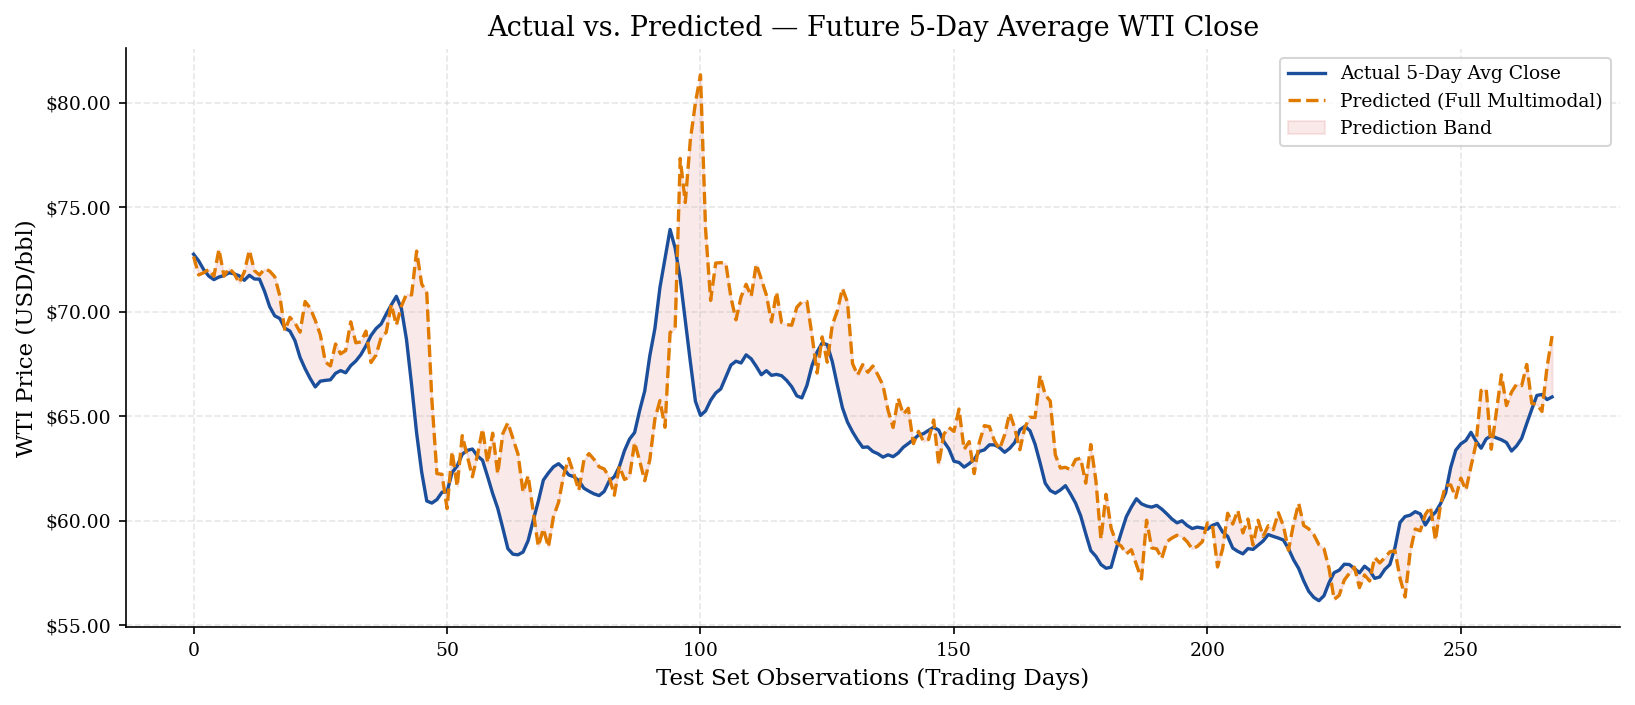

  -> Saved: /content/drive/MyDrive/bilstm/Outputs/Fig2_Residual_Distribution.png


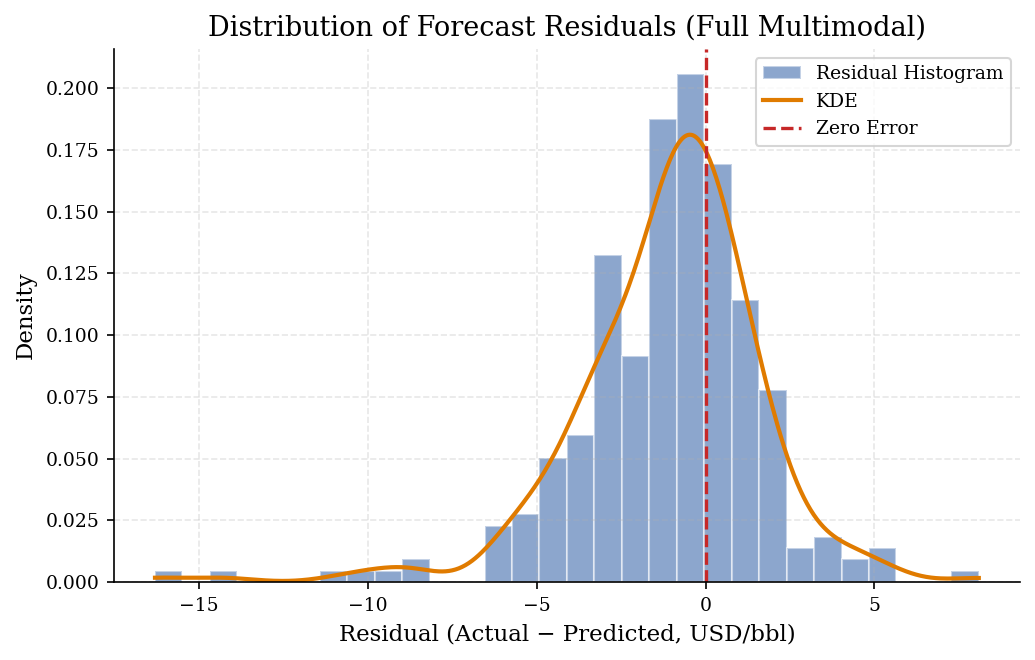

  -> Saved: /content/drive/MyDrive/bilstm/Outputs/Fig3_Scatter_Plot.png


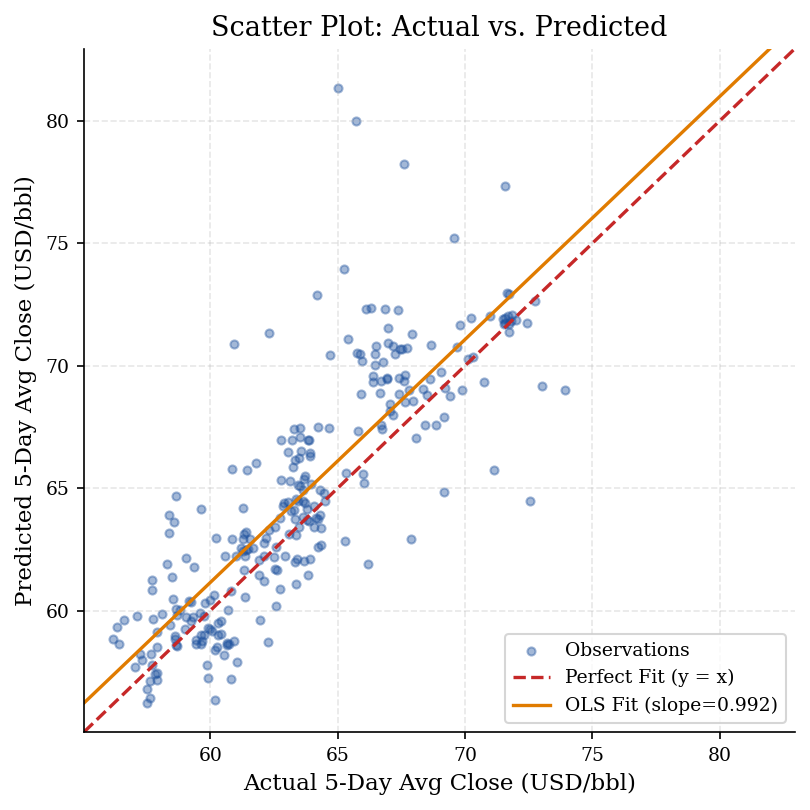

ALL CHARTS SUCCESSFULLY SAVED TO GOOGLE DRIVE.


In [16]:
# ======================================================================
# BLOCK 8: RESULTS VISUALIZATION (IEEE PUBLICATION STANDARD)
# ======================================================================
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Academic visualization style setup (IEEE)
plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "figure.dpi"        : 150,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "lines.linewidth"   : 1.6,
})

C_BLUE, C_ORANGE, C_GREEN, C_RED = "#1B4F9C", "#E07B00", "#2E7D32", "#C62828"

def save_plot(fig, filename):
    path = os.path.join(SAVE_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  -> Saved: {path}")

print("=" * 60)
print("GENERATING PUBLICATION VISUALIZATION CHARTS")
print("=" * 60)

if 'y_true_abl' not in globals() or 'full_model_preds' not in globals():
    raise ValueError("Error: y_true_abl or full_model_preds not found. Make sure Block 6 has been run.")

# 1. ACTUAL VS PREDICTED (Line Plot)
fig1, ax1 = plt.subplots(figsize=(11, 4.8))
n_plot = min(300, len(y_true_abl))
idx = np.arange(n_plot)

ax1.plot(idx, y_true_abl[:n_plot], color=C_BLUE, label="Actual 5-Day Avg Close", zorder=3)
ax1.plot(idx, full_model_preds[:n_plot], color=C_ORANGE, linestyle="--", label="Predicted (Full Multimodal)", zorder=4)
ax1.fill_between(idx, y_true_abl[:n_plot], full_model_preds[:n_plot], alpha=0.1, color=C_RED, label="Prediction Band")

ax1.set_xlabel("Test Set Observations (Trading Days)")
ax1.set_ylabel("WTI Price (USD/bbl)")
ax1.set_title("Actual vs. Predicted — Future 5-Day Average WTI Close")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.2f}"))
ax1.legend(loc="upper right")
fig1.tight_layout()
save_plot(fig1, "Fig1_Actual_vs_Predicted.png")
plt.show()

# 2. RESIDUAL HISTOGRAM
errors = y_true_abl - full_model_preds
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.hist(errors, bins=30, color=C_BLUE, alpha=0.5, density=True, label="Residual Histogram", edgecolor="white")

kde_x = np.linspace(errors.min(), errors.max(), 500)
kde = gaussian_kde(errors, bw_method="scott")
ax2.plot(kde_x, kde(kde_x), color=C_ORANGE, linewidth=2, label="KDE")
ax2.axvline(0, color=C_RED, linestyle="--", label="Zero Error")

ax2.set_xlabel("Residual (Actual − Predicted, USD/bbl)")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of Forecast Residuals (Full Multimodal)")
ax2.legend()
fig2.tight_layout()
save_plot(fig2, "Fig2_Residual_Distribution.png")
plt.show()

# 3. SCATTER PLOT
fig3, ax3 = plt.subplots(figsize=(5.5, 5.5))
lim_min = min(y_true_abl.min(), full_model_preds.min()) * 0.98
lim_max = max(y_true_abl.max(), full_model_preds.max()) * 1.02

ax3.scatter(y_true_abl, full_model_preds, alpha=0.4, s=15, color=C_BLUE, label="Observations")
ax3.plot([lim_min, lim_max], [lim_min, lim_max], color=C_RED, linestyle="--", label="Perfect Fit (y = x)")

coef = np.polyfit(y_true_abl, full_model_preds, 1)
trend_x = np.linspace(lim_min, lim_max, 200)
ax3.plot(trend_x, np.polyval(coef, trend_x), color=C_ORANGE, label=f"OLS Fit (slope={coef[0]:.3f})")

ax3.set_xlim(lim_min, lim_max)
ax3.set_ylim(lim_min, lim_max)
ax3.set_xlabel("Actual 5-Day Avg Close (USD/bbl)")
ax3.set_ylabel("Predicted 5-Day Avg Close (USD/bbl)")
ax3.set_title("Scatter Plot: Actual vs. Predicted")
ax3.legend()
fig3.tight_layout()
save_plot(fig3, "Fig3_Scatter_Plot.png")
plt.show()

print("=" * 60)
print("ALL CHARTS SUCCESSFULLY SAVED TO GOOGLE DRIVE.")
print("=" * 60)